### Overview

We are now ready to perform a large computation to create a median composite image for a city using XArray and Dask, leveraging STAC and DuckDB for querying cloud-hosted data sources.

### Overview of the Task

We will use the extracted city boundary from the previous step to query and load Sentinel-2 scenes for a chosen time-period and create a median composite. We will then clip and save the output as a Cloud-Optimized GeoTIFF (COG).


### Setup

Determine our runtime environment.


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
  !pip install pystac-client odc-stac rioxarray dask['distributed'] botocore \
      jupyter-server-proxy

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask
import matplotlib.pyplot as plt
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import pystac_client
import rioxarray as rxr
import xarray as xr
from odc.stac import configure_s3_access, load


Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

Read the GeoJSON.

In [ ]:
aoi_gdf = gpd.read_file(aoi_filepath)

Extract the geometry.

In [ ]:
geometry = aoi_gdf.geometry.union_all()
geometry

### Search and Load Sentinel-2 Imagery

Let's use Element84 search endpoint to look for items from the `sentinel-2-c1-l2a` collection on AWS. We search for the imagery collected within the date range and intersecting the AOI geometry.

We also specify additonal filters to select scenes based on metadata. The parameter `eo:cloud_cover` contains the overall cloud percentage and we use it to select imagery with < 30% overall cloud cover.

In [ ]:
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

# Configure settings for reading from Earth Search STAC
configure_s3_access(
    aws_unsigned=True,
)

# Search for images
# To ensure the process runs quickly, we will select images
# from a specific time range and with low cloud cover
year = 2023
start_month = 4
end_month = 5
time_range = f'{year}-{start_month:02d}/{year}-{end_month:02d}'

filters = {
    'eo:cloud_cover': {'lt': 30},
}

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=time_range,
    query=filters,
)
items = search.item_collection()
len(items)

Visualize the resulting image footprints. You can see that our AOI covers only a small part of a single scene. When we process the data for our AOI - we will only stream the required pixels to create the composite instead of downloading entire scenes.

In [ ]:
items_gdf = gpd.GeoDataFrame.from_features(items.to_dict(), crs='EPSG:4326')

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
items_gdf.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    alpha=0.5)

aoi_gdf.plot(
    ax=ax,
    facecolor='blue',
    alpha=0.5
)
ax.set_axis_off()
ax.set_title('STAC Query Results')
plt.show()

Load the matching images as a XArray Dataset.

In [ ]:
ds = load(
    items,
    bands=['red', 'green', 'blue', 'nir'],
    resolution=10,
    bbox=geometry.bounds,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
)
ds

The Sentinel-2 scenes come with NoData value of 0. So we set the correct NoData value before further processing.

In [ ]:
# Mask nodata values
ds = ds.where(ds != 0)

Apply scale and offset to all spectral bands

In [ ]:
scale = 0.0001
offset = -0.1
ds = ds*scale + offset

### Create a Median Composite
A very-powerful feature of XArray is the ability to easily aggregate data across dimensions - making it ideal for many remote sensing analysis. Let’s create a median composite from all the individual images.

We apply the `.median()` aggregation across the time dimension.

In [ ]:
median_composite = ds.median(dim='time')
median_composite

Select the required bands.

In [ ]:
rgb_composite = median_composite[['red', 'green', 'blue']]
rgb_composite

So far all the operations that we have created a computation graph. To run this computation using the local Dask cluster, we must call `.compute()`.

In [ ]:
%%time
rgb_composite = rgb_composite.compute()

### Visualize the Results

The composite is creating from all the pixels within the bounding box of the geometry. We can use `rioxarray` to clip the image to the city boundary to remove pixels outside the polygon.

To visualize our Dataset, we first convert it to a DataArray using the `to_array()` method. All the variables will be converted to a new dimension. Since our variables are image bands, we give the name of the new dimesion as band.


In [ ]:
rgb_composite_da = rgb_composite.to_array('band')
rgb_composite_da

In [ ]:
image_crs = rgb_composite_da.rio.crs
aoi_gdf_reprojected = aoi_gdf.to_crs(image_crs)
rgb_composite_clipped = rgb_composite_da.rio.clip(aoi_gdf_reprojected.geometry)
rgb_composite_clipped

For visualizing, we resample it to a lower resolution preview

In [ ]:
preview = rgb_composite_clipped.rio.reproject(
    rgb_composite_clipped.rio.crs, resolution=100
)

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    robust=True)
ax.set_title('RGB Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

We can manually apply a contrast stretch as well.

In [ ]:
percentile_stretch = (1, 95)
stretch_vmin, stretch_vmax = np.nanpercentile(preview.values, percentile_stretch)
print(stretch_vmin, stretch_vmax)

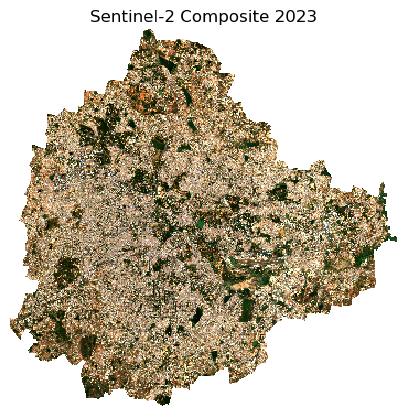

In [28]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    vmin=stretch_vmin,
    vmax=stretch_vmax)
ax.set_title(f'Sentinel-2 Composite {year}')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

### Export the Composite

We use the `rio` accessor to save the results as a Cloud-Optimized GeoTIFF.

In [ ]:
output_file = f'raw_composite_{year}.tif'
output_path = os.path.join(output_folder, output_file)
rgb_composite_clipped.rio.to_raster(output_path, driver='COG')
print(f'Wrote {output_path}')

The raw composite is suitable for downstream scientific analysis as it preserves the pixel reflectance values.Sometimes it is desirable to export the output as a colorized RGBA image. This visualized output suitable for use user-facing applications like basemaps or prints.

The `odc-geo` package provides a handy [`to_rgba()`](https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.to_rgba.html) function to save the visualized version of the composite. This function can be used via the `.odc` accessor.

In [ ]:
# Convert to a Xarray Dataset first
rgb_composite_ds = rgb_composite_clipped.to_dataset(dim='band')
composite_rgba = rgb_composite_ds.odc.to_rgba(
    vmin=stretch_vmin, vmax=stretch_vmax)


Save the visualized output.

In [ ]:
visualized_file = f'visualized_composite_{year}.tif'
visualized_output_path = os.path.join(output_folder, visualized_file)
composite_rgba.odc.write_cog(visualized_output_path, overwrite=True)
print(f'Wrote {visualized_output_path}')

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()

### Exercise

Create and export a median composites for years 2023 and 2025 for your city using the boundary extracted in the previous section.